### Seaborn : 고급 그래프
: Matplotlib의 기능과 스타일을 확장한 파이썬 시각 도구의 고급 버전

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

import warnings
warnings.filterwarnings('ignore')

In [5]:
titianic = sns.load_dataset('titanic')
titianic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 회귀선(기준선, 평균선)이 있는 산점도

In [6]:
sns.set_style('darkgrid')

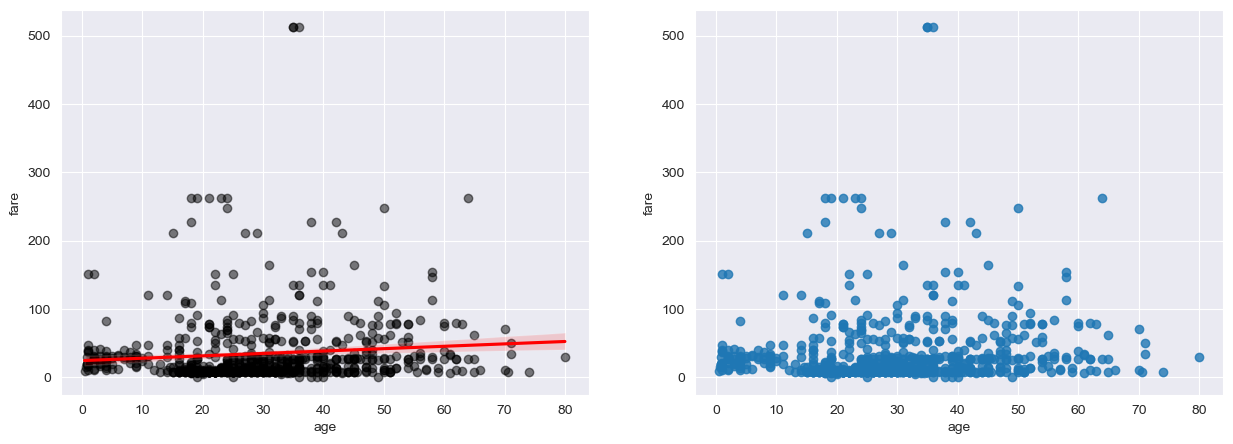

In [10]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# 선형회귀선 미표시
sns.regplot(
  x='age',
  y='fare',
  data=titianic,
  fit_reg=False,
  ax=ax2
)



# 선형회귀선 표시
sns.regplot(
  x='age',
  y='fare',
  data=titianic,
  fit_reg=True,
  ax=ax1,
  scatter_kws={
    'color' : 'black',
    'alpha' : 0.5
  },
  line_kws={
    'color' : 'red'
  }
)

plt.show()

In [13]:
import numpy as np
titianic.loc[:,['age','fare']].corr()
# np.corrcoef(titianic.age, titianic.fare)

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000


---
### 히트맵(heatmap)
: 2개의 데이터를 x,y에 놓고 데이터를 매트릭스 형태로 분류

In [17]:
# 객실별 성별숫자를 구하자 
table = \
  titianic.pivot_table(
    index=['sex'],
    columns=['pclass'],
    aggfunc='size' # 빈도수
  )
table

pclass,1,2,3
sex,,,
female,94,76,144
male,122,108,347


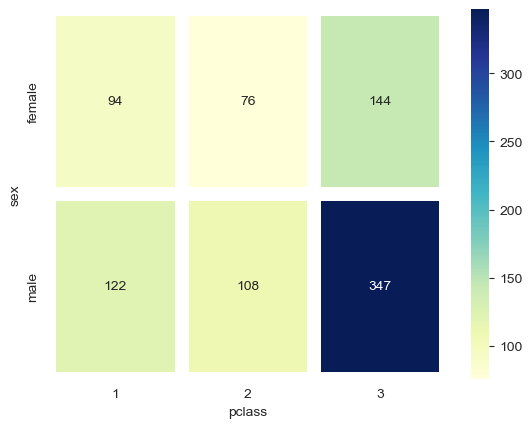

In [23]:
# 히트맵 그리기
sns.heatmap(
  table,
  annot=True,
  fmt='d',
  cmap='YlGnBu',
  linewidths=10
)

plt.show()

---
### 데이터 산포도

In [24]:
sns.set_style('whitegrid')

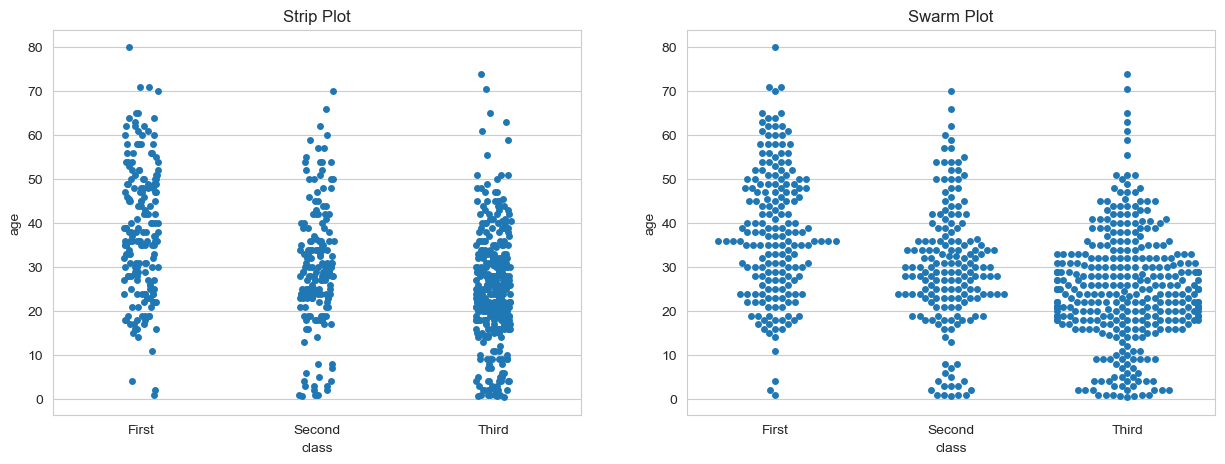

In [27]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

sns.stripplot(
  x='class',
  y='age',
  data=titianic,
  ax=ax1
)
ax1.set_title("Strip Plot")

# ----------------------

sns.swarmplot(
  x='class',
  y='age',
  data=titianic,
  ax=ax2
)

ax2.set_title('Swarm Plot')

plt.show()

---
### 막대(확률)그래프

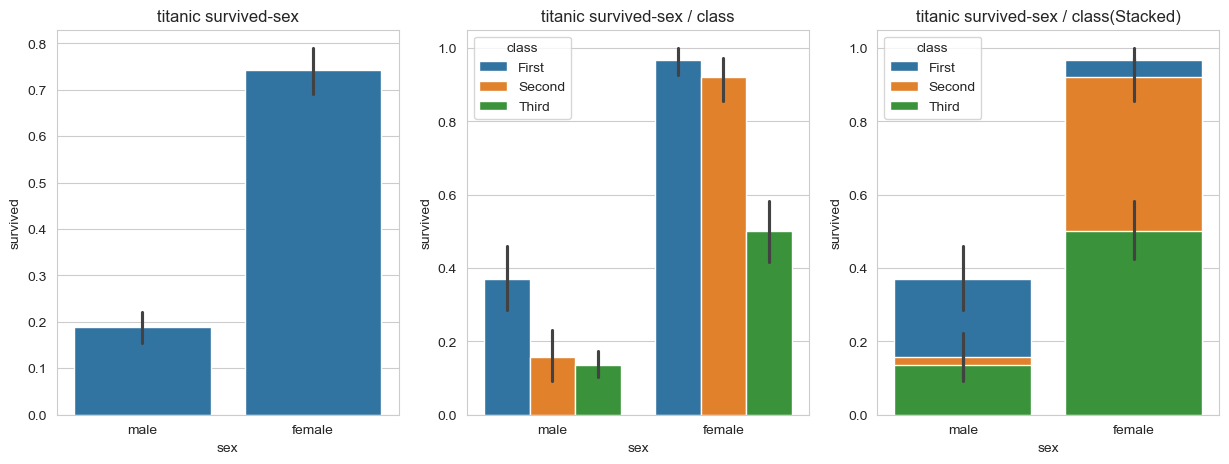

In [31]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)


sns.barplot(
  x='sex',
  y='survived',
  data=titianic,
  ax=ax1
)

ax1.set_title('titanic survived-sex')

#------------------------------------


sns.barplot(
  x='sex',
  y='survived',
  hue='class',
  data=titianic,
  ax=ax2
)

ax2.set_title('titanic survived-sex / class')

#------------------------------------


sns.barplot(
  x='sex',
  y='survived',
  hue='class',
  data=titianic,
  dodge=False,
  ax=ax3
)

ax3.set_title('titanic survived-sex / class(Stacked)')

#------------------------------------
plt.show()

---
### 빈도그래프

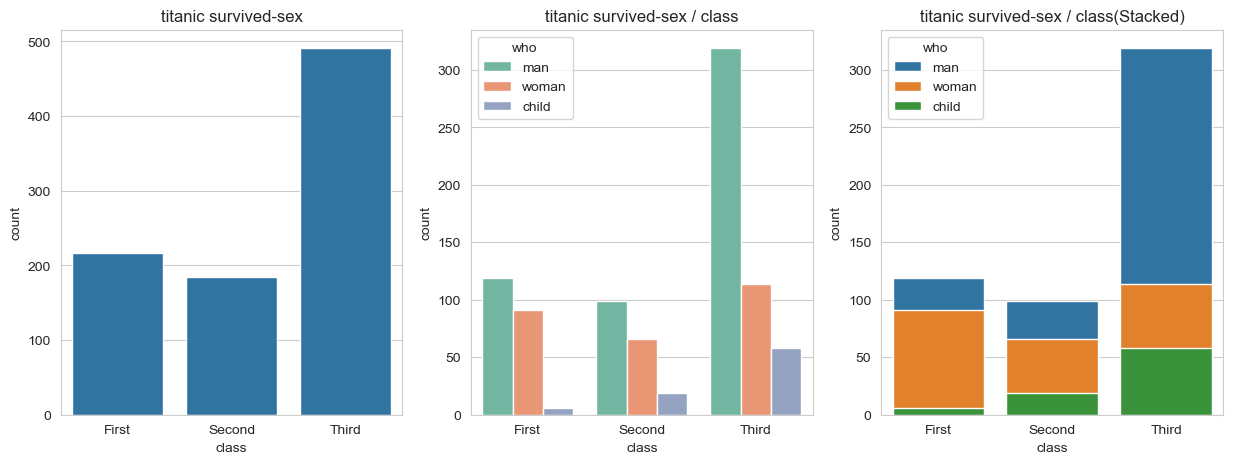

In [36]:
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)


sns.countplot(
  x='class',
  data=titianic,
  ax=ax1
)

ax1.set_title('titanic survived-sex')

#------------------------------------


sns.countplot(
  x='class',
  hue='who',
  data=titianic,
  palette='Set2',
  ax=ax2
)

ax2.set_title('titanic survived-sex / class')

#------------------------------------


sns.countplot(
  x='class',
  hue='who',
  data=titianic,
  dodge=False,
  ax=ax3
)

ax3.set_title('titanic survived-sex / class(Stacked)')

#------------------------------------
plt.show()

---
### 박스 플롯/ 바이올린 그래프
: 박스플롯은 데이터의 분포와 주요 통계지표를 제공하지만 데이터가 퍼져있는 분산의 정도를 알기 어렵다

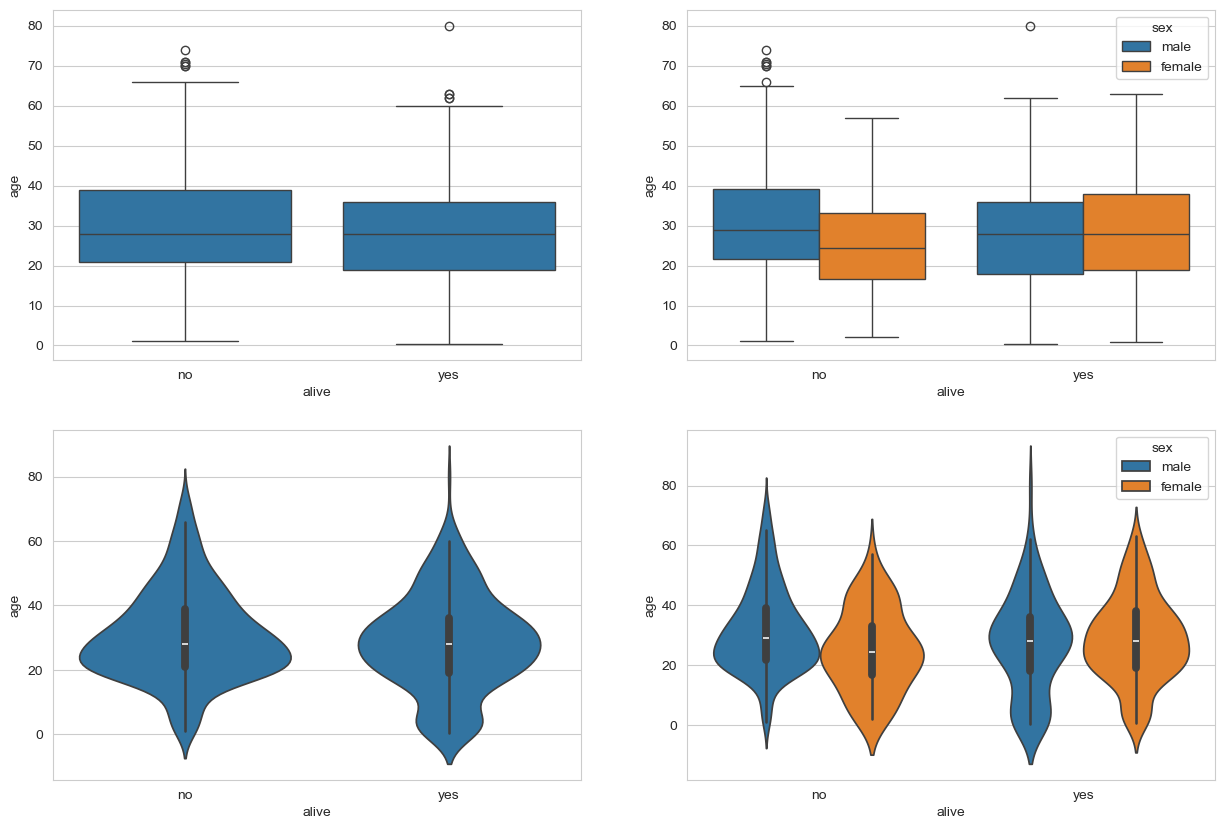

In [42]:
fig = plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

# 박스 플롯

sns.boxplot(
  x='alive',
  y='age',
  data=titianic,
  ax=ax1
)


# 박스 플롯, 성별 추가

sns.boxplot(
  x='alive',
  y='age',
  hue='sex',
  data=titianic,
  ax=ax2
)

# 바이올린 그래프

sns.violinplot(
  x='alive',
  y='age',
  data=titianic,
  ax=ax3
)

# 바이올린 그래프, 성별추가

sns.violinplot(
  x='alive',
  y='age',
  hue='sex',
  data=titianic,
  ax=ax4
)


plt.show()


---
### 조인트 그래프
: 산점도를 기본으로 하고 각 축에 대한 히스토그램을 동시 제공

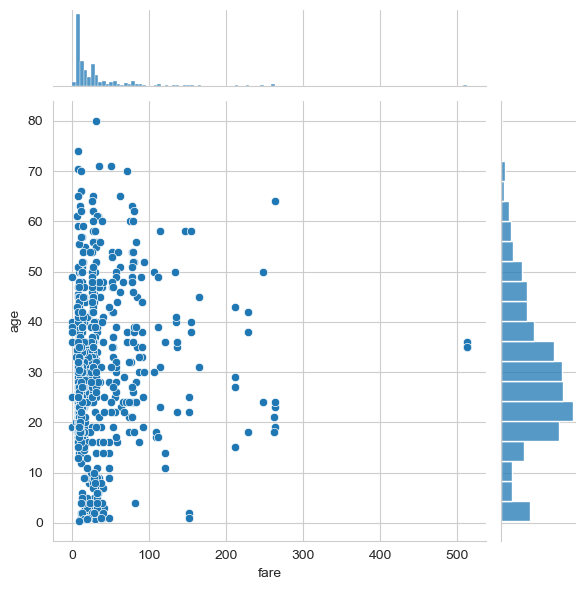

In [43]:
# 기본값
sns.jointplot(
  x='fare',
  y='age',
  data=titianic
)

plt.show()

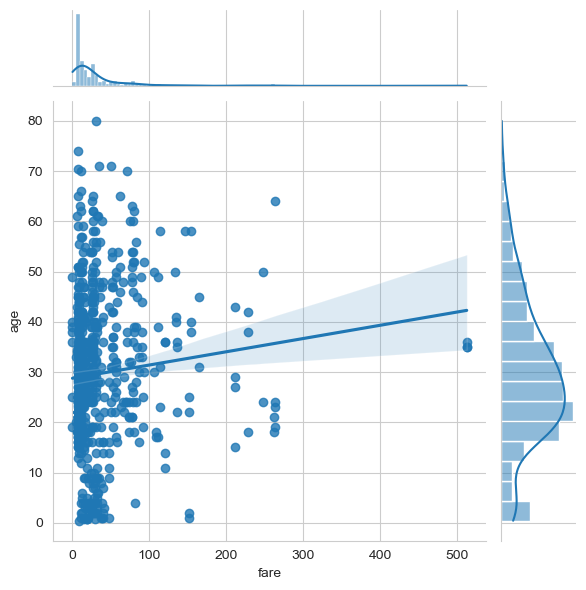

In [44]:
# 회귀선
sns.jointplot(
  x='fare',
  y='age',
  kind='reg',
  data=titianic
)

plt.show()

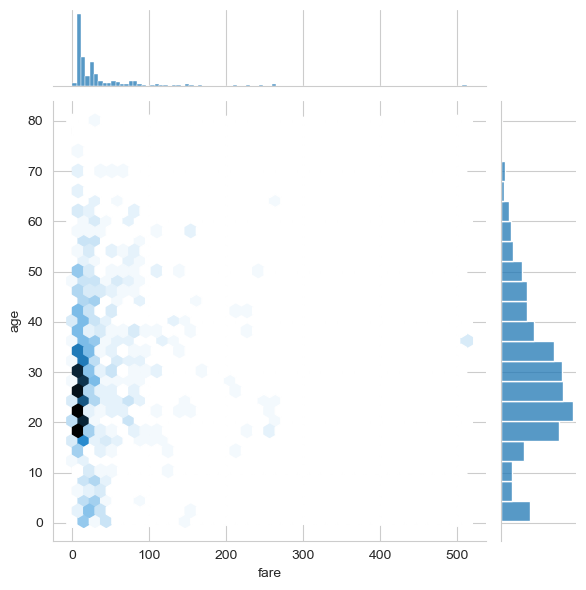

In [45]:
# 육각 그래프
sns.jointplot(
  x='fare',
  y='age',
  kind='hex',
  data=titianic
)

plt.show()

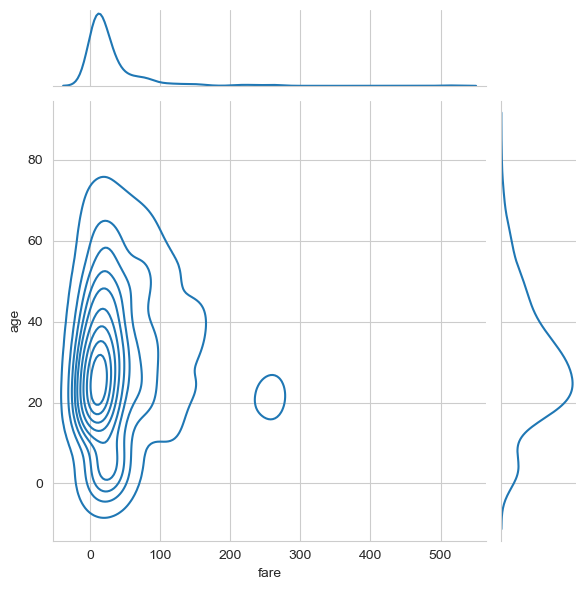

In [46]:
# 밀집 그래프
sns.jointplot(
  x='fare',
  y='age',
  kind='kde',
  data=titianic
)

plt.show()